In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/masou

In [2]:
import os
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Conv2D, MaxPooling2D, Dense, Flatten,Rescaling
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array, array_to_img
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf

2026-04-05 21:10:36.776909: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775423437.009471      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775423437.074915      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775423437.615773      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775423437.615816      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775423437.615819      55 computation_placer.cc:177] computation placer alr

In [ ]:
img_sz = 220
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training",
    image_size=(img_sz,img_sz),
    batch_size=batch_size,

)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing",
    image_size=(img_sz,img_sz),
    batch_size=batch_size,


)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


I0000 00:00:1775423464.715187      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775423464.721274      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [4]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0



base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(img_sz,img_sz, 3)
)

base_model.trainable = False 
for layer in base_model.layers[:]:
    layer.trainable=True

from tensorflow.keras.applications.efficientnet import preprocess_input

inputs = tf.keras.Input(shape=(220, 220, 3))

x = inputs 

x = base_model(x, training=True)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,

)

Epoch 1/10


2026-04-05 21:18:00.310151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-05 21:18:00.462078: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 167ms/step - accuracy: 0.7297 - loss: 0.7218 - val_accuracy: 0.8781 - val_loss: 0.4039
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9542 - loss: 0.1368 - val_accuracy: 0.8938 - val_loss: 0.3849
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9814 - loss: 0.0584 - val_accuracy: 0.9281 - val_loss: 0.3531
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9563 - val_loss: 0.2836
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9949 - loss: 0.0213 - val_accuracy: 0.9531 - val_loss: 0.2743
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9962 - loss: 0.0149 - val_accuracy: 0.9594 - val_loss: 0.2968
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9949 - loss: 0.0162 - val_accuracy: 0.9656 - val_loss: 0.2725
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9945 - loss: 0.0197 - val

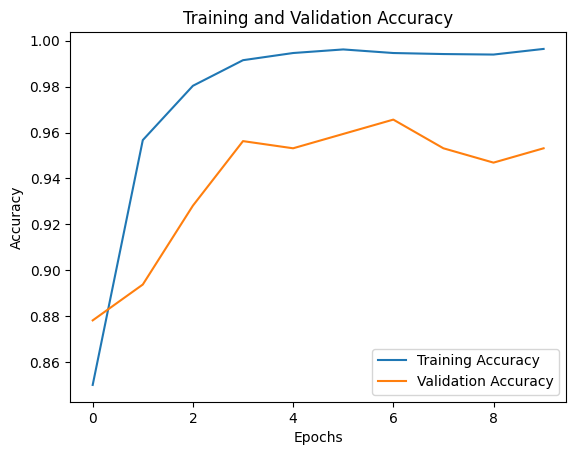

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [27]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary'] 

In [31]:
 from tensorflow.keras.preprocessing import image
def predict_disease(img_path):
    img = image.load_img(img_path, target_size=(220, 220))  
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    a=np.argmax(model.predict(img_array))
    return class_names[a]

In [32]:
predict_disease('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training/notumor/Tr-no_10.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


'notumor'